# V2.22 — Metadata-Aware Clinical V2 Classifier (Ablation)

**Issue:** [#173](https://github.com/romanpoluden/revela/issues/173)
**Branch:** `clinical_v2_16_17_18`
**Date:** 2026-05-25
**Author:** Rehma Aziz
**Scope:** Test whether available non-image metadata (body location, age, sex) improves the Clinical V2 image-only EfficientNet-B0 baseline on the frozen 5-class test split. Experiment only — no model promotion, no registry / taxonomy / app change, no inference wiring change.

---

## Outcome Summary

**Metadata does NOT improve the Clinical V2 baseline — recommend discontinuing this line under current data conditions.** Across all four fusion variants on the frozen test set (n=1,515), no variant produces a trustworthy gain over the same-run image-only baseline (macro-F1 0.6527, SCIN 0.4267, lesion-routing FN 70):

- The best pooled number, `image_body_parts` (+0.0104 combined macro-F1), does **not** improve on `google_scin` — the only source that actually carries metadata — where macro-F1 is flat-to-lower (0.4267 → 0.4238), and it **increases** safety-critical lesion-routing false negatives (70 → 74).
- `image_body_parts_age` degrades SCIN hardest (0.4267 → 0.3743); `image_body_parts_age_sex` has the worst lesion FN (82).
- This was predicted **before** training: body location / age / sex are recorded almost exclusively on SCIN (≈0% on Fitzpatrick17k), giving a HIGH shortcut risk (Cramér's V = 0.508 between body_parts-presence and the class label). The fusion model cannot learn a source-independent use of metadata, so a pooled bump reflects the source confound rather than clinical signal.

A metadata-aware model also **cannot be deployed** unless the app collects this metadata at submission time (today it collects images only) — see the Product Note. **No model is promoted; this is an experiment only.**

> This is an educational model-evaluation experiment. The lesion class is a **routing output for dermoscopic review, not cancer detection**. No diagnostic or clinical-readiness claims are made.

## Setup

In [1]:
import hashlib
import json
import math

import matplotlib.pyplot as plt
import pandas as pd

ROOT = "../../.."  # repo root relative to this notebook

TRAIN_PATH   = f"{ROOT}/data/processed/clinical_v2/train.csv"
TEST_PATH    = f"{ROOT}/data/processed/clinical_v2/test.csv"
ABLATION_CSV = f"{ROOT}/outputs/metrics/clinical_v2_metadata_ablation_table.csv"
METRICS_JSON = f"{ROOT}/outputs/metrics/clinical_v2_metadata_candidate_metrics.json"

ORDER = ["image_only", "image_body_parts", "image_age",
         "image_body_parts_age", "image_body_parts_age_sex"]
COLORS = ["#7f8c8d"] + ["#3498db"] * 4  # baseline grey, metadata variants blue

# Frozen test-split fingerprint (issue #173) — verified before/after every train & eval run.
test_hash = hashlib.md5(open(TEST_PATH, "rb").read()).hexdigest()
print("Test hash:", test_hash)
assert test_hash == "4b510381927f6265446a62cb990e69fd", "Test split changed — STOP"
print("Frozen test split verified.")

Test hash: 4b510381927f6265446a62cb990e69fd
Frozen test split verified.


## Section 1 — Metadata Audit & Shortcut Risk (pre-registered, before training)

The priority fields named in the issue (`body_location`, `age_bucket`, `sex`) do not exist verbatim in the
`clinical_v2` schema. They map to **12 binary `body_parts_*` columns**, `age_group`, and `sex_at_birth`.
The critical fact is *where* these are populated.

In [2]:
train = pd.read_csv(TRAIN_PATH, dtype=str).fillna("")

BODY_PARTS_COLS = [
    "body_parts_head_or_neck", "body_parts_arm", "body_parts_palm",
    "body_parts_back_of_hand", "body_parts_torso_front", "body_parts_torso_back",
    "body_parts_genitalia_or_groin", "body_parts_buttocks", "body_parts_leg",
    "body_parts_foot_top_or_side", "body_parts_foot_sole", "body_parts_other",
]
train["body_parts_any"] = (train[BODY_PARTS_COLS].apply(lambda c: c.str.strip()) != "").any(axis=1)

def cov(df, col):
    return round((df[col].astype(str).str.strip() != "").mean() * 100, 1)

rows = []
for src, g in train.groupby("source_dataset"):
    rows.append({
        "source": src,
        "n": len(g),
        "body_parts_any %": round(g["body_parts_any"].mean() * 100, 1),
        "age_group %": cov(g, "age_group"),
        "sex_at_birth %": cov(g, "sex_at_birth"),
        "fitzpatrick_skin_type %": cov(g, "fitzpatrick_skin_type"),
    })
print("Metadata coverage by source (train split):")
pd.DataFrame(rows).set_index("source")

Metadata coverage by source (train split):


,n,body_parts_any %,age_group %,sex_at_birth %,fitzpatrick_skin_type %
source,,,,,
fitzpatrick17k,4447,0.0,0.0,0.0,0.0
google_scin,2539,85.7,100.0,100.0,60.1


In [3]:
def cramers_v(df, col, label_col="target_label"):
    """Cramér's V between a categorical column and the class label (matches train-script audit)."""
    sub = df[[col, label_col]].copy()
    sub[col] = sub[col].astype(str).str.strip().replace("", "unknown")
    ct = pd.crosstab(sub[col], sub[label_col]).values.astype(float)
    n = ct.sum()
    if n == 0 or min(ct.shape) < 2:
        return 0.0
    expected = ct.sum(1, keepdims=True) @ ct.sum(0, keepdims=True) / n
    chi2 = ((ct - expected) ** 2 / expected).sum()
    k = min(ct.shape)
    return math.sqrt(chi2 / (n * (k - 1)))

train["__bp_any__"] = train["body_parts_any"].map({True: "YES", False: ""})

shortcut = []
for f in ["age_group", "sex_at_birth", "fitzpatrick_skin_type", "__bp_any__"]:
    v = cramers_v(train, f)
    name = "body_parts (any filled)" if f == "__bp_any__" else f
    shortcut.append({
        "field": name,
        "Cramér's V": round(v, 3),
        "risk": "HIGH" if v > 0.4 else "MODERATE" if v > 0.2 else "LOW",
    })
print("Cramér's V vs class label (computed BEFORE any training):")
pd.DataFrame(shortcut).set_index("field")

Cramér's V vs class label (computed BEFORE any training):


,Cramér's V,risk
field,,
age_group,0.284,MODERATE
sex_at_birth,0.325,MODERATE
fitzpatrick_skin_type,0.200,LOW
body_parts (any filled),0.508,HIGH


**Read this before trusting any improvement.** `body_parts`, `age_group`, and `sex_at_birth` are populated for
~86–100% of `google_scin` rows and **0%** of `fitzpatrick17k` rows. So "metadata is present" is almost
equivalent to "this is a SCIN row", and the two sources have different class mixes. That is exactly why
`body_parts`-presence scores **Cramér's V = 0.508 (HIGH)** against the class label.

Consequence: any combined-test-set gain could be the model exploiting the *source* signal rather than learning
clinical body-location reasoning. The decisive check is therefore **per-source** macro-F1 (Section 4), not the
pooled number.

## Section 2 — Architecture & Parameter Budget

Image backbone is the existing Clinical V2 EfficientNet-B0 (torchvision, ImageNet). Metadata is encoded
(body_parts multi-hot, age ordinal+unknown-flag, sex one-hot — missing → explicit zeros/unknown, no row dropped),
passed through a small MLP, concatenated with the 1280-dim image embedding, then a linear head. The metadata
branch is constrained to **< 5% of total params** so image evidence stays dominant; `source_dataset` is **never**
a model input (asserted in the constructor).

| Component | Params | % of total |
|---|---:|---:|
| EfficientNet-B0 backbone | ~5.27M | ~99.98% |
| Metadata MLP (body_parts, dim=12) | ~944 | ~0.02% |
| Metadata MLP (body_parts+age, dim=14) | ~1,008 | ~0.02% |
| Metadata MLP (body_parts+age+sex, dim=17) | ~1,104 | ~0.02% |

Training config matches the baseline exactly: AdamW lr 1e-4, weight_decay 0.01, inverse-frequency class weights,
no sampler, seed 42, 5 epochs, batch 16.

## Section 3 — Ablation Table (frozen test set, n=1,515)

Δ and the shortcut flag are computed against the **same-run image-only re-eval** (macro-F1 0.6527), not a stale
historical constant. `shortcut? = CHECK` fires when pooled macro-F1 rises > +0.01 while SCIN macro-F1 does not.

In [4]:
ablation = pd.read_csv(ABLATION_CSV)
show = ablation[[
    "variant", "combined_macro_f1", "balanced_accuracy", "google_scin_macro_f1",
    "fitzpatrick17k_macro_f1", "lesion_routing_fn", "delta_vs_baseline_mf1", "shortcut_risk",
]].copy()
show.columns = ["variant", "combined mF1", "bal acc", "SCIN mF1", "Fitz17k mF1",
                "lesion FN", "Δ mF1 vs base", "shortcut?"]
show.set_index("variant").round(4)

,combined mF1,bal acc,SCIN mF1,Fitz17k mF1,lesion FN,Δ mF1 vs base,shortcut?
variant,,,,,,,
image_only,0.6527,0.6612,0.4267,0.6644,70,0.0000,OK
image_body_parts,0.6631,0.6800,0.4238,0.6632,74,0.0104,CHECK
image_age,0.6460,0.6617,0.4136,0.6518,70,-0.0067,OK
image_body_parts_age,0.6440,0.6663,0.3743,0.6498,72,-0.0087,OK
image_body_parts_age_sex,0.6520,0.6633,0.4266,0.6458,82,-0.0006,OK


## Section 4 — Per-Source Breakdown (the diagnostic)

SCIN is the only source that carries metadata. If metadata helped clinically, SCIN macro-F1 would rise.
Fitzpatrick17k rows always receive a zeros/unknown metadata vector, so the metadata branch contributes no
signal there — its column is a sanity check that adding the branch does not hurt the image-only path.

In [5]:
metrics = json.load(open(METRICS_JSON))
per_source = pd.DataFrame({
    "combined mF1":  {v: metrics[v]["combined_macro_f1"] for v in ORDER},
    "SCIN mF1":      {v: metrics[v]["google_scin_macro_f1"] for v in ORDER},
    "Fitz17k mF1":   {v: metrics[v]["fitzpatrick17k_macro_f1"] for v in ORDER},
    "lesion FN":     {v: metrics[v]["lesion_routing_fn"] for v in ORDER},
})
base = metrics["image_only"]
per_source["SCIN Δ vs base"] = per_source["SCIN mF1"] - base["google_scin_macro_f1"]
per_source.round(4)

,combined mF1,SCIN mF1,Fitz17k mF1,lesion FN,SCIN Δ vs base
image_only,0.6527,0.4267,0.6644,70,0.0000
image_body_parts,0.6631,0.4238,0.6632,74,-0.0030
image_age,0.6460,0.4136,0.6518,70,-0.0131
image_body_parts_age,0.6440,0.3743,0.6498,72,-0.0524
image_body_parts_age_sex,0.6520,0.4266,0.6458,82,-0.0002


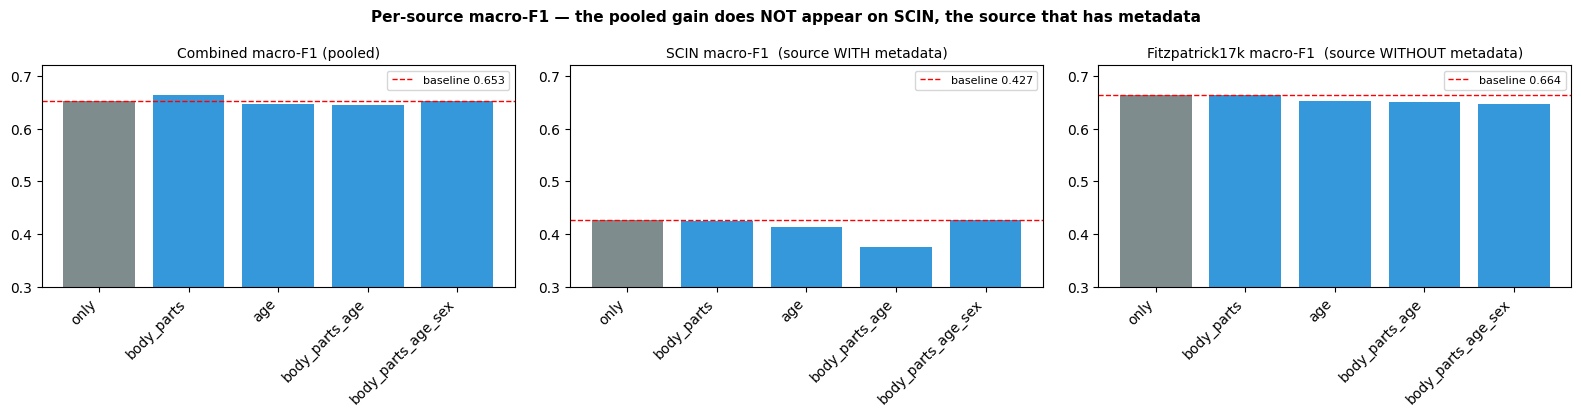

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
panels = [
    ("combined_macro_f1",       "Combined macro-F1 (pooled)"),
    ("google_scin_macro_f1",    "SCIN macro-F1  (source WITH metadata)"),
    ("fitzpatrick17k_macro_f1", "Fitzpatrick17k macro-F1  (source WITHOUT metadata)"),
]
for ax, (key, title) in zip(axes, panels):
    vals = [metrics[v][key] for v in ORDER]
    ax.bar(range(len(ORDER)), vals, color=COLORS)
    ax.axhline(base[key], color="red", ls="--", lw=1, label=f"baseline {base[key]:.3f}")
    ax.set_xticks(range(len(ORDER)))
    ax.set_xticklabels([v.replace("image_", "") for v in ORDER], rotation=45, ha="right")
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0.30, 0.72)
    ax.legend(fontsize=8)
plt.suptitle("Per-source macro-F1 — the pooled gain does NOT appear on SCIN, the source that has metadata",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

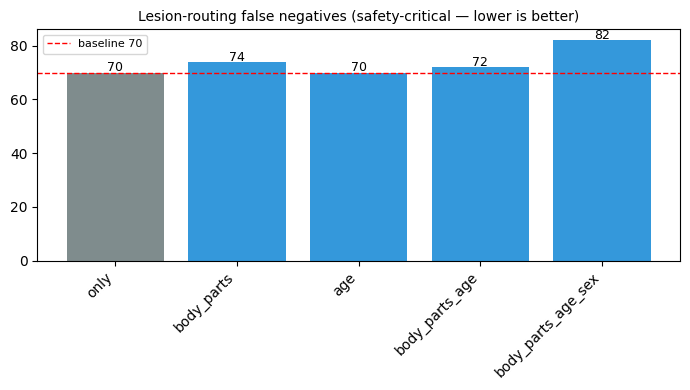

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
fns = [metrics[v]["lesion_routing_fn"] for v in ORDER]
ax.bar(range(len(ORDER)), fns, color=COLORS)
ax.axhline(base["lesion_routing_fn"], color="red", ls="--", lw=1,
           label=f"baseline {base['lesion_routing_fn']}")
for i, f in enumerate(fns):
    ax.text(i, f + 0.4, str(f), ha="center", fontsize=9)
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels([v.replace("image_", "") for v in ORDER], rotation=45, ha="right")
ax.set_title("Lesion-routing false negatives (safety-critical — lower is better)", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Section 5 — Promotion Verdict & Recommendation

Verdict thresholds use the same-run baseline (macro-F1 0.6527, bal-acc 0.6612, SCIN 0.4267, lesion FN 70).
A variant must pass **all** criteria to be promotable.

| Variant | macro-F1 > 0.6527 | bal-acc stable | SCIN ≥ 0.4267−0.005 | lesion FN ≤ 70 | Verdict |
|---|---|---|---|---|---|
| image_body_parts | PASS | PASS | PASS | **FAIL** | **FAIL** |
| image_age | FAIL | PASS | FAIL | PASS | **FAIL** |
| image_body_parts_age | FAIL | PASS | FAIL | FAIL | **FAIL** |
| image_body_parts_age_sex | FAIL | PASS | PASS | FAIL | **FAIL** |

**Recommendation: discontinue metadata-aware modeling for Clinical V2 under current data conditions.** The best
pooled variant (`image_body_parts`, +0.0104) does not improve SCIN (Δ −0.0030) and regresses lesion-routing FN
(70 → 74). The pooled movement reflects source-correlated metadata (HIGH shortcut risk, Cramér's V 0.508), not
generalizable clinical signal. Because body_parts/age/sex are present almost only on SCIN (≈0% on Fitzpatrick17k),
the fusion model cannot learn a source-independent use of metadata.

### Product Note (CRITICAL)

> A metadata-aware model **cannot be deployed without app-side metadata collection.** The app currently submits
> images only, so every inference would receive an all-unknown (zeros) metadata vector — an inference path the
> model was not trained or evaluated under. Body location must be collected from the user at submission time for
> metadata fusion to be even potentially meaningful. No metadata-aware variant should be promoted until that
> collection UI exists and is validated.

## Summary

| Item | Value |
|---|---|
| Task | V2.22 — metadata-aware Clinical V2 ablation (#173) |
| Variants | image_body_parts, image_age, image_body_parts_age, image_body_parts_age_sex |
| Baseline (same-run re-eval) | macro-F1 0.6527 · SCIN 0.4267 · lesion FN 70 |
| Best pooled variant | image_body_parts 0.6631 (+0.0104) — **but SCIN −0.0030, lesion FN +4** |
| Pre-registered shortcut risk | body_parts↔label Cramér's V 0.508 (HIGH); metadata ≈0% on Fitzpatrick17k |
| Promotable variants | **none** |
| Recommendation | Discontinue metadata fusion under current data conditions |
| Test hash | `4b510381927f6265446a62cb990e69fd` ✓ (verified before & after every run) |

**Out of scope — confirmed:** no model promoted in code, no inference registry change, no taxonomy change, no
Streamlit/app UI change, no app metadata collection implemented, no clinical-readiness claims.

**Artifacts:** `docs/model/clinical_v2_metadata_aware_model_summary.md`,
`docs/model/clinical_v2_metadata_availability_summary.md`,
`outputs/metrics/clinical_v2_metadata_ablation_table.csv`,
`outputs/metrics/clinical_v2_metadata_candidate_metrics.json`.